In [1]:
import scipy.ndimage.measurements
import numpy as np
import os
import pandas
import logging
import psutil
logging.basicConfig(filename='LogVoidAnalysis.log', level=logging.DEBUG)
import h5py
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import time

In [2]:
key = "../api_key.txt"

with open(key) as file :
    api_key = file.read()


In [3]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":f"{api_key}"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    
    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string
    
    return r

In [4]:
data = np.load("../data/simulations/illustris3/illustris3_z0_positions.npz")
pos = np.column_stack([data["x_pos"], data["y_pos"], data["z_pos"]])
print("loaded", len(pos), "subhalos")

loaded 121209 subhalos


In [5]:
from PIL import Image
with Image.open("../figures/illustris3_clean_slice.png") as im:
    data = im.getdata()

print(data)

In [6]:
data.getpixel((0,0))

(255, 255, 255, 255)

In [7]:
width, height = im.size

voids = np.zeros((width, height))
for i in range(width):
    for j in range(height):
        try:
            rgb = data.getpixel((i,j))
            if rgb[0] > 235 and rgb[1] > 235 and rgb[2] > 235:
                voids[i,j] = True
            else:
                voids[i,j] = False
        except:
            break
#voids = voids[voids != -1]
voids.shape

(1200, 1200)

In [8]:
len(voids[voids == True])

769626

In [9]:
la, nf = scipy.ndimage.measurements.label(voids)

C:\Users\mika2\AppData\Local\Temp\ipykernel_29664\3357307679.py:1: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  la, nf = scipy.ndimage.measurements.label(voids)


In [10]:
la

array([[   1,    1,    1, ...,   41,   41,   41],
       [   1,    1,    1, ...,   41,   41,   41],
       [   1,    1,    1, ...,   41,   41,   41],
       ...,
       [4655, 4655, 4655, ...,   41,   41,   41],
       [4655, 4655, 4655, ...,    0,    0,    0],
       [4655, 4655, 4655, ...,    0,    0,    0]],
      shape=(1200, 1200), dtype=int32)

In [11]:
nf

6186

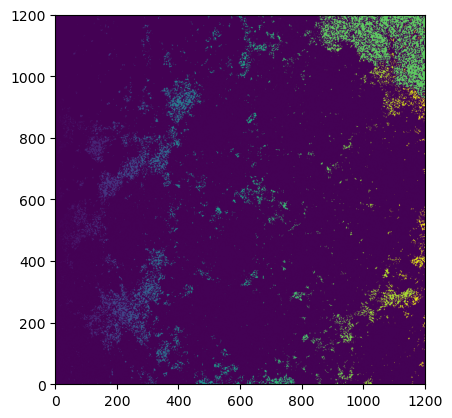

In [12]:
plt.imshow(la.T, extent=[0, width, 0, height])

C:\Users\mika2\AppData\Local\Temp\ipykernel_29664\1428972256.py:18: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  la, nf = scipy.ndimage.measurements.label(voids)


cutoff 255: 769,626 void pixels, 6186 structures
cutoff 245: 769,626 void pixels, 6186 structures
cutoff 235: 769,626 void pixels, 6186 structures


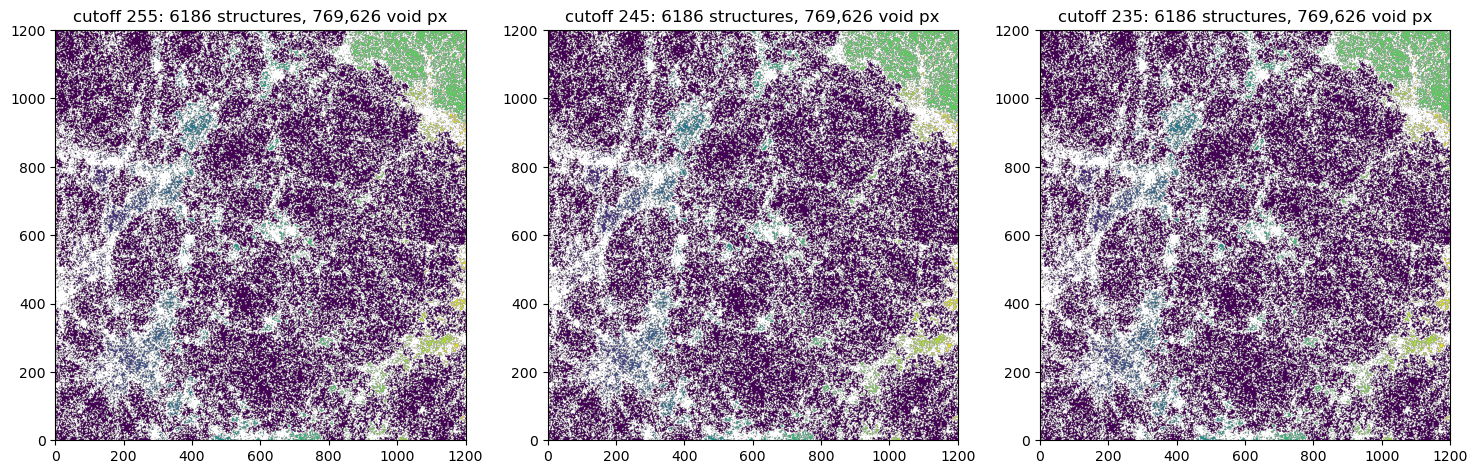

In [13]:
thresholds = [255, 245, 235]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, thresh in zip(axes, thresholds):
    voids = np.zeros((width, height))
    for i in range(width):
        for j in range(height):
            try:
                rgb = data.getpixel((i, j))
                if rgb[0] >= thresh and rgb[1] >= thresh and rgb[2] >= thresh:
                    voids[i, j] = True
                else:
                    voids[i, j] = False
            except:
                break

    la, nf = scipy.ndimage.measurements.label(voids)
    n_void_px = len(voids[voids == True])

    la_plot = la.T.astype(float)
    la_plot[la_plot == 0] = np.nan          # background -> transparent -> white

    ax.imshow(la_plot, extent=[0, width, 0, height])
    ax.set_title(f"cutoff {thresh}: {nf} structures, {n_void_px:,} void px")
    print(f"cutoff {thresh}: {n_void_px:,} void pixels, {nf} structures")

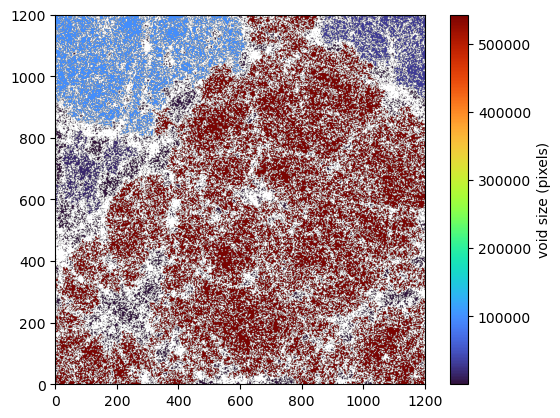

In [14]:
from scipy.ndimage import uniform_filter

window = 21
density = uniform_filter(voids.astype(float), size=window)   # 0..1 = void fraction nearby

sizes = np.bincount(la.ravel())          # size of each labelled blob
sizes[0] = 0                             # background
size_map = sizes[la].astype(float)
size_map[size_map == 0] = np.nan         # background transparent
im = plt.imshow(size_map.T, extent=[0, width, 0, height], cmap='turbo')
plt.colorbar(im, label='void size (pixels)')

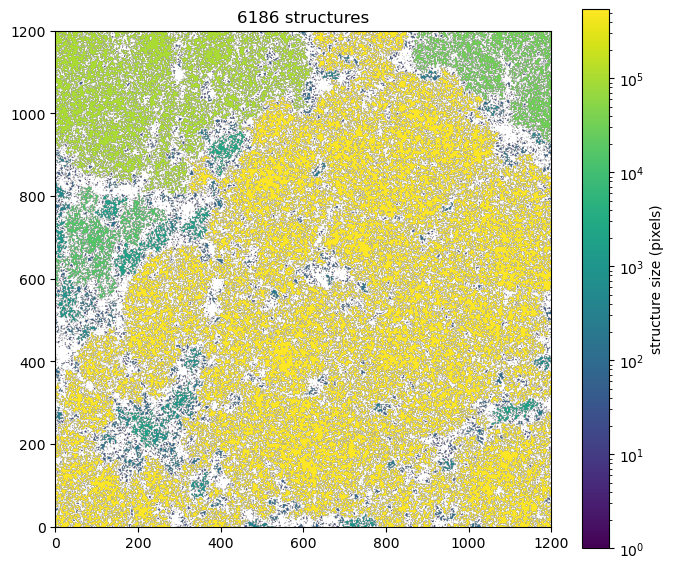

In [15]:
from scipy.ndimage import label
from matplotlib.colors import LogNorm

la, nf = label(voids)

sizes = np.bincount(la.ravel())
sizes[0] = 0                     # background
size_map = sizes[la].astype(float)
size_map[size_map == 0] = np.nan # non-void stays white

plt.figure(figsize=(8, 7))
im = plt.imshow(size_map.T, extent=[0, width, 0, height], cmap='viridis',
                norm=LogNorm(vmin=max(1, sizes[sizes>0].min()), vmax=sizes.max()))
plt.colorbar(im, label='structure size (pixels)')
plt.title(f'{nf} structures')
plt.show()

C:\Users\mika2\AppData\Local\Temp\ipykernel_29664\1497388199.py:21: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  la, nf = scipy.ndimage.measurements.label(voids)


cutoff 255: 769,626 void pixels, 6186 structures
cutoff 245: 769,626 void pixels, 6186 structures
cutoff 235: 769,626 void pixels, 6186 structures


C:\Users\mika2\AppData\Local\Temp\ipykernel_29664\1497388199.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


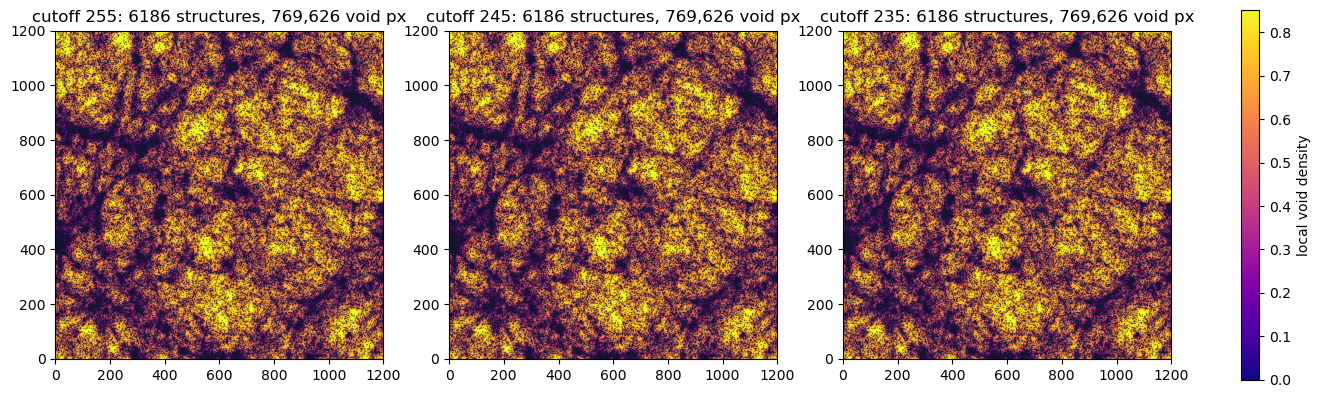

In [16]:
from scipy.ndimage import gaussian_filter

thresholds = [255, 245, 235]
sigma = 8 
cmap_name, bg = 'plasma', '#14142b'     

results = []
for thresh in thresholds:
    voids = np.zeros((width, height))
    for i in range(width):
        for j in range(height):
            try:
                rgb = data.getpixel((i, j))
                if rgb[0] >= thresh and rgb[1] >= thresh and rgb[2] >= thresh:
                    voids[i, j] = True
                else:
                    voids[i, j] = False
            except:
                break

    la, nf = scipy.ndimage.measurements.label(voids)
    n_void_px = len(voids[voids == True])

    mask = voids.astype(bool)
    density = gaussian_filter(mask.astype(float), sigma=sigma)  
    dmap = density.T.copy()
    dmap[~mask.T] = np.nan          
    results.append((thresh, nf, n_void_px, dmap))
    print(f"cutoff {thresh}: {n_void_px:,} void pixels, {nf} structures")

vmax = np.nanpercentile(np.concatenate([r[3][~np.isnan(r[3])].ravel() for r in results]), 99)

cmap = plt.cm.get_cmap(cmap_name).copy()
cmap.set_bad(bg)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (thresh, nf, n_void_px, dmap) in zip(axes, results):
    ax.set_facecolor(bg)
    im = ax.imshow(dmap, extent=[0, width, 0, height], cmap=cmap, vmin=0, vmax=vmax)
    ax.set_title(f"cutoff {thresh}: {nf} structures, {n_void_px:,} void px")

fig.colorbar(im, ax=axes, label='local void density', shrink=0.8)
plt.show()

In [ ]:
#confirm what the range of rgb values are (for the weird case if there are values >255)
